# Timeline executor: scrape dates, bucket eras, validate

Runs the plan from `02_plan.ipynb`. Three stages:

1. **Mini-scrape** — re-fetch each character page and pull `Born` / `Died` from the infobox. We don't need to redo affiliation parsing — just the two new fields.
2. **Date parsing + cascade** — turn raw infobox strings into integers, fall back to book subsections and bio events.
3. **Validate** — bar chart of era distribution + era × Louvain community heatmap.

## 1. Mini-scrape: Born / Died only

Reuses the v2 scraper's session + user-agent. Pulls just `Born` and `Died` rows from each character's infobox. ~3,689 pages at 8 workers ≈ 8–10 min.

**Output:** `dates.csv` with columns `ID, born_raw, died_raw`. Raw strings — parsing happens in stage 2.

In [3]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
from urllib.parse import quote, unquote
from concurrent.futures import ThreadPoolExecutor

BASE = 'https://awoiaf.westeros.org'
PREFIX = '/index.php/'
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
}
session = requests.Session()
session.headers.update(headers)

def slug_to_url(slug):
    return BASE + PREFIX + quote(slug, safe="_/(),'")


def scrape_dates(row):
    slug = row['ID']
    try:
        resp = session.get(slug_to_url(slug), timeout=20)
    except requests.RequestException:
        return {'ID': slug, 'born_raw': '', 'died_raw': ''}
    if resp.status_code != 200:
        return {'ID': slug, 'born_raw': '', 'died_raw': ''}
    soup = BeautifulSoup(resp.content, 'html.parser')
    info = soup.find('table', class_='infobox')
    born, died = '', ''
    if info:
        for tr in info.find_all('tr'):
            th = tr.find('th'); td = tr.find('td')
            if not th or not td:
                continue
            label = th.get_text(strip=True).rstrip(':').lower()
            value = td.get_text(' ', strip=True)
            if label == 'born' and not born:
                born = value
            elif label == 'died' and not died:
                died = value
    return {'ID': slug, 'born_raw': born, 'died_raw': died}


characters = pd.read_csv('../csvs/characters.csv').to_dict('records')
print(f'{len(characters)} characters to scrape for Born/Died')

rows = []
with ThreadPoolExecutor(max_workers=8) as ex:
    for i, r in enumerate(ex.map(scrape_dates, characters), 1):
        rows.append(r)
        if i % 200 == 0:
            print(f'  {i}/{len(characters)}')

dates_df = pd.DataFrame(rows)
dates_df.to_csv('dates.csv', index=False)
print(f'Saved {len(dates_df)} rows. Coverage:')
print(f'  Born populated: {(dates_df["born_raw"] != "").sum()}')
print(f'  Died populated: {(dates_df["died_raw"] != "").sum()}')
print(f'  Either:         {((dates_df["born_raw"] != "") | (dates_df["died_raw"] != "")).sum()}')


3690 characters to scrape for Born/Died
  200/3690
  400/3690
  600/3690
  800/3690
  1000/3690
  1200/3690
  1400/3690
  1600/3690
  1800/3690
  2000/3690
  2200/3690
  2400/3690
  2600/3690
  2800/3690
  3000/3690
  3200/3690
  3400/3690
  3600/3690
Saved 3690 rows. Coverage:
  Born populated: 1412
  Died populated: 1179
  Either:         2003


## 2. Parse dates + run the cascade

Born/Died strings look like `123 AC`, `Around 270 AC`, `In 282 AC, at Storm's End`, etc. We pull the first `(\d+)\s*(AC|BC)` match. Fall back to book subsections and bio events for characters with no infobox date.

**Source priority** (from `02_plan.ipynb`):
1. Infobox `Died`
2. Infobox `Born` + 30
3. Has any ASOIAF book h3 subsection → 300 AC
4. Bio mentions an anchored event → year of that event
5. Otherwise → Unknown

In [4]:
import re
from collections import Counter

YEAR_RE = re.compile(r'\b(\d{1,4})\s*(AC|BC)\b')
EVENTS = {
    "Aegon's Conquest":      0,
    'Dance of the Dragons':   130,
    'Faith Militant':         45,
    'Blackfyre Rebellion':    196,
    "Robert's Rebellion":    283,
    'Greyjoy Rebellion':      289,
    "War of the Five Kings": 300,
}

# Fine-grained eras (kept for backwards compatibility)
ERAS = [
    ('Pre-Conquest',        None,  1),
    ('Targaryen Conquest',     1,  50),
    ('Fire & Blood',          50, 200),
    ('Mid-Targaryen',        200, 250),
    ('Late Targaryen',       250, 283),
    ("Robert's Reign",       283, 298),
    ('ASOIAF main',          298, 310),
]

# Coarser book buckets — what the v3 network actually separates by.
# Boundaries chosen to match publication-series narrative scope.
BOOK_BUCKETS = [
    ('Fire & Blood',           None, 200),  # Pre-Conquest + Conquest + F&B proper
    ('Tales of Dunk & Egg',     200, 250),  # Hedge Knight novellas era
    ('A Song of Ice and Fire',  250, 310),  # Main series + immediate prior generation
]


def parse_year(raw):
    if not raw:
        return None
    m = YEAR_RE.search(raw)
    if not m:
        return None
    y = int(m.group(1))
    return -y if m.group(2) == 'BC' else y


def assign_era(year):
    if year is None:
        return 'Unknown'
    for name, lo, hi in ERAS:
        if name == 'Pre-Conquest' and year < hi:
            return name
        if lo is not None and hi is not None and lo <= year < hi:
            return name
    return 'Unknown'


def assign_book_bucket(year):
    if year is None:
        return 'Unknown'
    for name, lo, hi in BOOK_BUCKETS:
        if lo is None and year < hi:
            return name
        if lo is not None and lo <= year < hi:
            return name
    return 'Unknown'


bios = pd.read_csv('../csvs/characters_bio.csv').fillna('')
bio_by_id = dict(zip(bios['ID'], bios['bio']))
BOOK_TITLES = ['A Game of Thrones', 'A Clash of Kings', 'A Storm of Swords',
               'A Feast for Crows', 'A Dance with Dragons', 'The Winds of Winter']


def has_asoiaf_book(bio):
    return any(b in bio for b in BOOK_TITLES)


def cascade_year_and_source(cid, born_raw, died_raw, bio):
    died = parse_year(died_raw)
    if died is not None:
        return died, 'died'
    born = parse_year(born_raw)
    if born is not None:
        return born + 30, 'born+30'
    if has_asoiaf_book(bio):
        return 300, 'book_mention'
    if bio:
        for ev, year in EVENTS.items():
            if ev in bio:
                return year, f'event:{ev}'
    return None, 'unknown'


dates_df = pd.read_csv('dates.csv').fillna('')
records = []
for _, r in dates_df.iterrows():
    cid = r['ID']
    bio = bio_by_id.get(cid, '')
    year, source = cascade_year_and_source(cid, r['born_raw'], r['died_raw'], bio)
    records.append({
        'ID': cid,
        'year': year,
        'source': source,
        'era': assign_era(year),
        'book_bucket': assign_book_bucket(year),
    })

eras_df = pd.DataFrame(records)
eras_df.to_csv('eras.csv', index=False)

print('Source coverage:')
print(eras_df['source'].value_counts().to_string())
print()
print('Fine-grained era distribution:')
print(eras_df['era'].value_counts().to_string())
print()
print('Coarser book-bucket distribution:')
print(eras_df['book_bucket'].value_counts().to_string())


FileNotFoundError: [Errno 2] No such file or directory: '../characters_bio.csv'

## 3. Validation: era distribution + era × community heatmap

Two plots. First — overall era distribution. We expect ASOIAF main to dominate. Second — cross-tab of era against Louvain community: if the temporal smear is real, the Crownlands community should split when stratified by era.

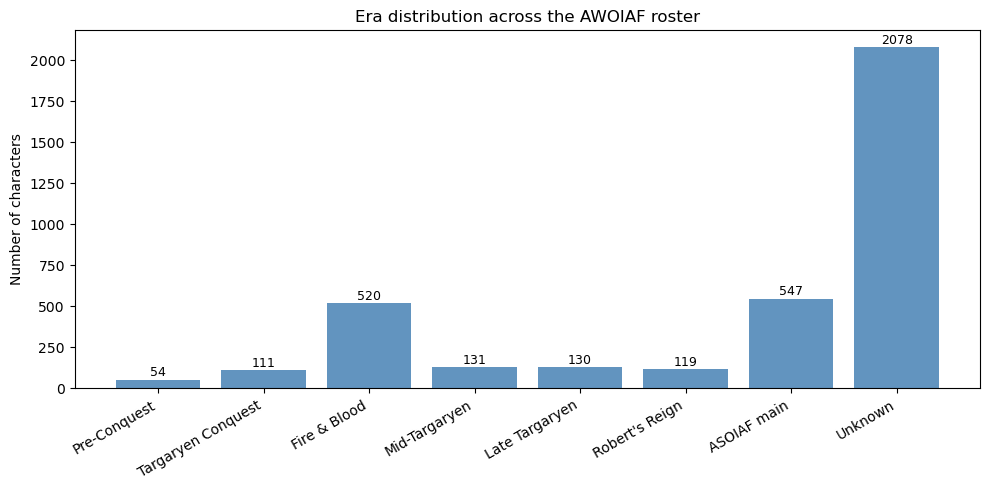

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot 1: era distribution
era_counts = eras_df['era'].value_counts()
ORDER = ['Pre-Conquest', 'Targaryen Conquest', 'Fire & Blood', 'Mid-Targaryen',
         'Late Targaryen', "Robert's Reign", 'ASOIAF main', 'Unknown']
era_counts = era_counts.reindex(ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(era_counts.index, era_counts.values, color='steelblue', alpha=0.85)
for i, v in enumerate(era_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)
ax.set_ylabel('Number of characters')
ax.set_title('Era distribution across the AWOIAF roster')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


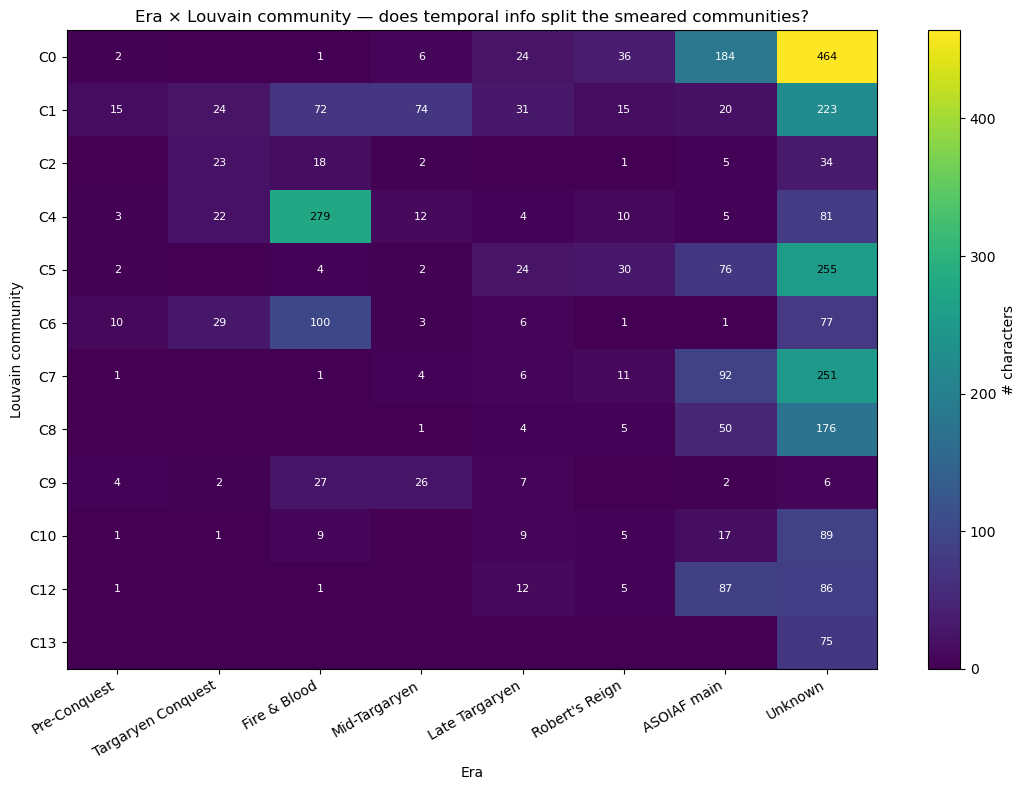

In [ ]:
# Plot 2: era x Louvain community
region_df = pd.read_csv('../csvs/community_vs_region.csv').fillna('')
merged = region_df.merge(eras_df[['ID', 'era']], on='ID', how='left')
merged['era'] = merged['era'].fillna('Unknown')

# Use top communities only
top_comms = merged['community'].value_counts().head(12).index
sub = merged[merged['community'].isin(top_comms)]
cross = pd.crosstab(sub['community'], sub['era'])
cross = cross.reindex(columns=[c for c in ORDER if c in cross.columns], fill_value=0)

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(cross.values, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(cross.columns))); ax.set_xticklabels(cross.columns, rotation=30, ha='right')
ax.set_yticks(range(len(cross.index))); ax.set_yticklabels([f'C{c}' for c in cross.index])
ax.set_xlabel('Era'); ax.set_ylabel('Louvain community')
ax.set_title('Era × Louvain community — does temporal info split the smeared communities?')
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        v = cross.iloc[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8,
                    color='white' if v < cross.values.max() / 2 else 'black')
plt.colorbar(im, ax=ax, label='# characters')
plt.tight_layout(); plt.show()


## What to look for in the heatmap

**Signal of success:** a community that previously looked like one Westerosi region splits horizontally across multiple eras. For example, if the Crownlands community shows substantial counts in both `Fire & Blood` and `ASOIAF main` columns, that confirms the smear hypothesis — that community is *Targaryen dynasty across all time*, not *Crownlands as a place*.

**Signal of failure / instability:** Unknown era dominates every row, or eras are uniformly distributed across communities. Either case means the cascade didn't recover enough signal for the era information to be analytically useful.

**Next step if it works:** drop graph edges where source and target eras differ by ≥ 2 buckets, re-run Louvain on the filtered graph, compare modularity and per-region purity to the v2 baseline. That would be the proper fix for the temporal smear caveat documented in the explainer.

**If it doesn't:** report the failure as discussion material. The honest finding — *we tried to time-slice the graph and the data didn't support it cleanly* — is itself rubric-relevant (dimension 6: limitations awareness).